In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [11]:
path = "C:/Users/mikan/Documents/ds4300/practical02/src/stats"
dfs = []

for file in os.listdir(path):
    if file.endswith("_search.csv"):  
        file_path = os.path.join(path, file) 
        df = pd.read_csv(file_path)  
        dfs.append(df) 

if dfs: 
    final_df = pd.concat(dfs, ignore_index=True)  
else:
    print("No CSV files found in the directory.")

#final_df

C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\2684525567.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(dfs, ignore_index=True)


In [12]:
path = "C:/Users/mikan/Documents/ds4300/practical02/src/stats"
dfs = []

for file in os.listdir(path):
    if file.endswith("_processing.csv"):  
        file_path = os.path.join(path, file) 
        df = pd.read_csv(file_path)  
        dfs.append(df) 

if dfs: 
    proc_df = pd.concat(dfs, ignore_index=True)    
else:
    print("No CSV files found in the directory.")
proc_df

C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\2253854004.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  proc_df = pd.concat(dfs, ignore_index=True)


,vector_db,embedding_model,peak_memory_mb,total_processing_time,docs_processed,chunks_processed,chunk_size,chunk_overlap
0,chroma,all-mpnet-base-v2,13.660134,45.920271,13,207,100,20
1,chroma,nomic-embed-text,1.036328,58.876756,13,207,100,20
2,chroma,hkunlp/instructor-xl,13.877860,483.915498,13,207,100,20
3,redis,all-mpnet-base-v2,31.814040,226.533075,13,207,100,20
4,redis,nomic-embed-text,0.784557,45.631941,13,207,100,20
5,redis,hkunlp/instructor-xl,32.932830,1056.201541,13,207,100,20
6,redis,all-mpnet-base-v2,31.814368,186.561317,13,207,100,20
7,redis,all-mpnet-base-v2,29.689445,199.450236,13,115,200,20
8,redis,nomic-embed-text,0.788122,55.907550,13,115,200,20
9,redis,hkunlp/instructor-xl,22.402221,813.178215,13,115,200,20


C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\2085752313.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=dbs)


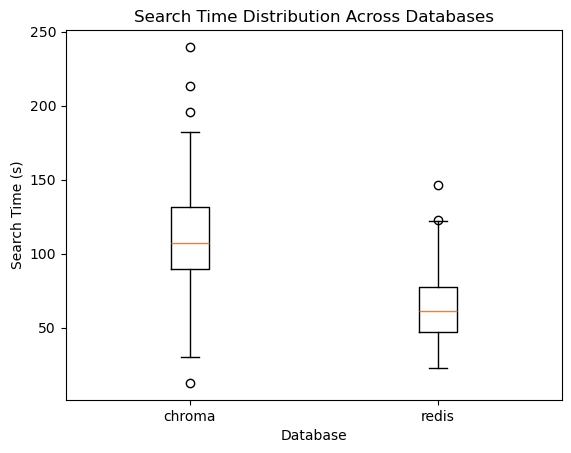

In [4]:
## 1. Boxplot: Query Time Distribution by Database
dbs = final_df[" database"].unique()
data = [final_df[final_df[" database"] == db][" total_time"].dropna() for db in dbs]
plt.boxplot(data, labels=dbs)
plt.title("Search Time Distribution Across Databases")
plt.xlabel("Database")
plt.ylabel("Search Time (s)")
plt.show()

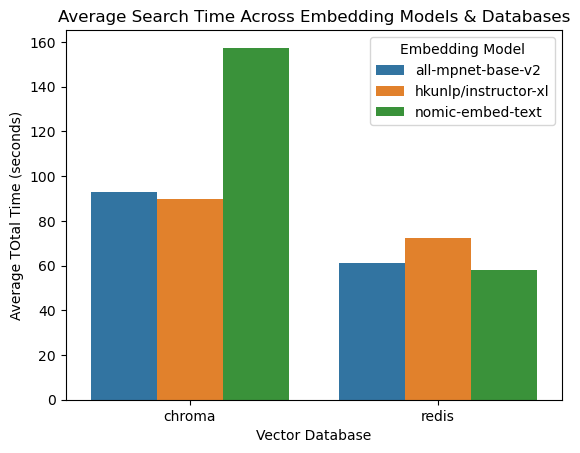

In [5]:
avg_query_time = final_df.groupby([" database", " embedding_model"])[" total_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x=" database", y=" total_time", hue=" embedding_model")
plt.title("Average Search Time Across Embedding Models & Databases")
plt.xlabel("Vector Database")
plt.ylabel("Average TOtal Time (seconds)")
plt.legend(title="Embedding Model")
plt.show()

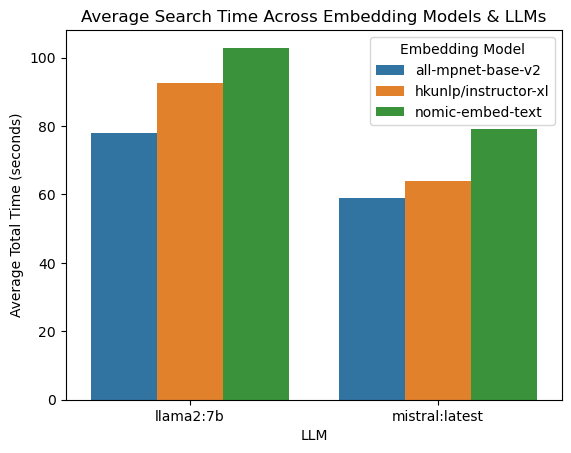

In [6]:
avg_query_time = final_df.groupby([" llm", " embedding_model"])[" total_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x=" llm", y=" total_time", hue=" embedding_model")
plt.title("Average Search Time Across Embedding Models & LLMs")
plt.xlabel("LLM")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="Embedding Model")
plt.show()

C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\4260302500.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=dbs)


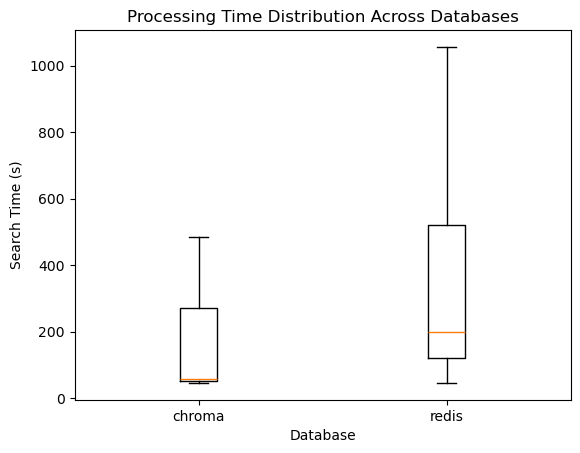

In [7]:
dbs = proc_df["vector_db"].unique()
data = [proc_df[proc_df["vector_db"] == db]["total_processing_time"].dropna() for db in dbs]
plt.boxplot(data, labels=dbs)
plt.title("Processing Time Distribution Across Databases")
plt.xlabel("Database")
plt.ylabel("Search Time (s)")
plt.show()

C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\3264380432.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=avg_query_time, x="chunk_size", y="total_processing_time", hue = "embedding_model",ci=None)


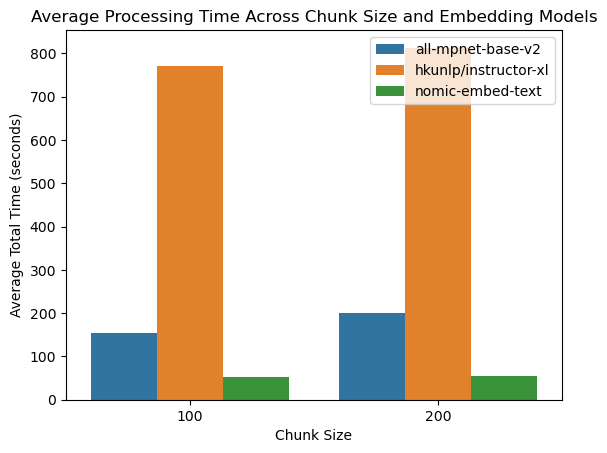

In [8]:
avg_query_time = proc_df.groupby(["chunk_size", "embedding_model"])["total_processing_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x="chunk_size", y="total_processing_time", hue = "embedding_model",ci=None)
plt.title("Average Processing Time Across Chunk Size and Embedding Models")
plt.xlabel("Chunk Size")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="")
plt.show()

C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\1511185741.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=avg_query_time, x="chunk_size", y="total_processing_time", hue = "vector_db",ci=None)


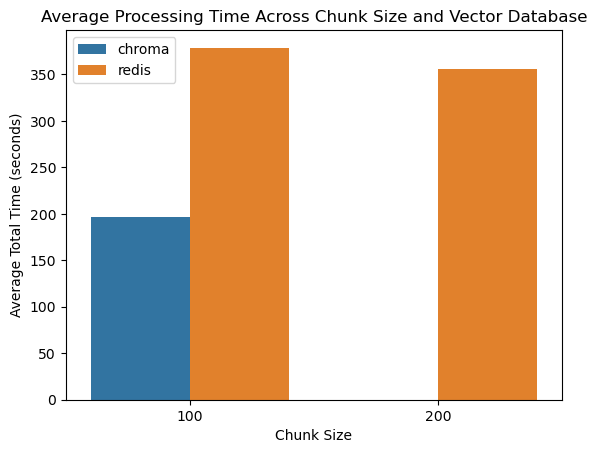

In [16]:
avg_query_time = proc_df.groupby(["chunk_size", "vector_db"])["total_processing_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x="chunk_size", y="total_processing_time", hue = "vector_db",ci=None)
plt.title("Average Processing Time Across Chunk Size and Vector Database")
plt.xlabel("Chunk Size")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="")
plt.show()

C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\1867246455.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=avg_query_time, x="embedding_model", y="peak_memory_mb", hue = "vector_db",ci=None)


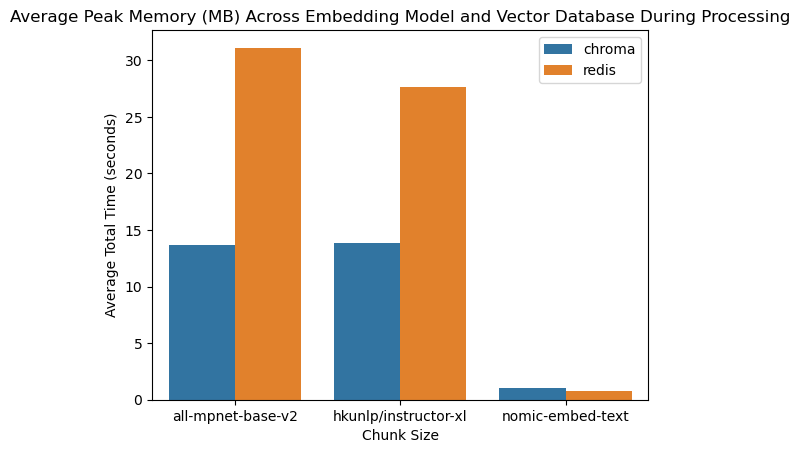

In [21]:
avg_query_time = proc_df.groupby(["embedding_model", "vector_db"])["peak_memory_mb"].mean().reset_index()
sns.barplot(data=avg_query_time, x="embedding_model", y="peak_memory_mb", hue = "vector_db",ci=None)
plt.title("Average Peak Memory (MB) Across Embedding Model and Vector Database During Processing")
plt.xlabel("Chunk Size")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="")
plt.show()

C:\Users\mikan\AppData\Local\Temp\ipykernel_34412\902575677.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=dbs)


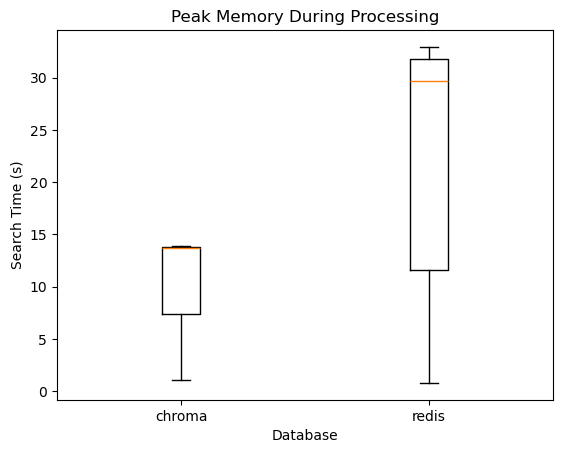

In [14]:
## 1. Boxplot: Query Time Distribution by Database
dbs = proc_df["vector_db"].unique()
data = [proc_df[proc_df["vector_db"] == db]["peak_memory_mb"].dropna() for db in dbs]
plt.boxplot(data, labels=dbs)
plt.title("Peak Memory During Processing")
plt.xlabel("Database")
plt.ylabel("Search Time (s)")
plt.show()

In [ ]:
avg_query_time = proc_df.groupby(["peak_memory_mb", "vector_db"])["peak_memory_mb"].mean().reset_index()
sns.barplot(data=avg_query_time, x="chunk_size", y="peak_memory_mb", hue = "vector_db",ci=None)
plt.title("Average Processing Time Across Chunk Size and Embedding Models")
plt.xlabel("Chunk Size")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="")
plt.show()